,step,sensors_state,stacked_state,q_values,action,timestamp
0,0,"(0.16874999999999996, 0.0625, 0.07499999999999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-6.9689693, -8.337138, -7.432572, -4.79104, -...",3,1.765235e+09


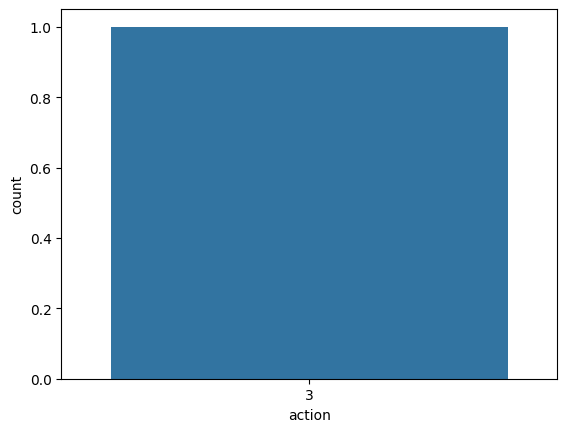

In [ ]:
import pandas as pd
import seaborn as sns

df = pd.read_pickle("../robot_data_log.pkl")
sns.countplot(x='action', data=df)

In [4]:
import plotly as plt
# Pega a diferença entre a melhor ação e a segunda melhor
def calculate_confidence(q_values):
    sorted_q = sorted(q_values, reverse=True)
    return sorted_q[0] - sorted_q[1]

df['confidence'] = df['q_values'].apply(calculate_confidence)

# Plota a confiança ao longo do tempo
plt.plot(df['step'], df['confidence'])

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

<Axes: xlabel='sensor_center', ylabel='q_fwd'>

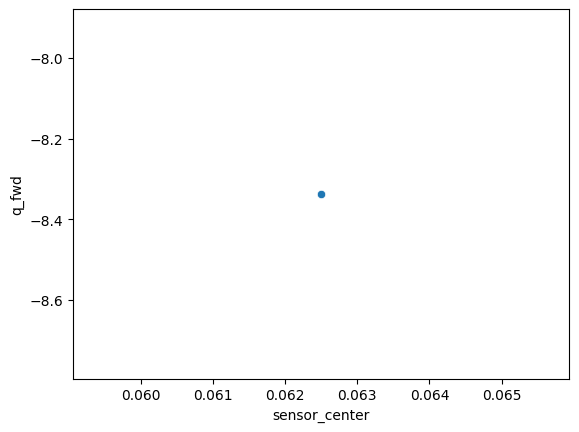

In [12]:
# Extrai o valor do sensor central de cada linha
df['sensor_center'] = df['sensors_state'].apply(lambda x: x[1])
df['sensor_left'] = df['sensors_state'].apply(lambda x: x[0])
df['sensor_right'] = df['sensors_state'].apply(lambda x: x[2])

# Extrai o Q-Value da ação 'Frente' (índice 1)
df['q_fwd'] = df['q_values'].apply(lambda x: x[1])
df['q_left'] = df['q_values'].apply(lambda x: x[3])

# Scatter Plot
sns.scatterplot(x='sensor_center', y='q_fwd', data=df)

In [14]:
from sklearn.decomposition import PCA
import numpy as np

# Transforma a coluna de arrays em uma matriz
X = np.stack(df['stacked_state'].values)

print(X.shape)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Plota colorindo pela ação que ele tomou
plt.scatter(X_2d[:,0], X_2d[:,1], c=df['action'], cmap='viridis')

(1, 24)


ValueError: n_components=2 must be between 0 and min(n_samples, n_features)=1 with svd_solver='full'